In [1]:
#Projet portfolio - E-commerce Olist
#Etape 2 : EDA - 4 KPI prioritaires + visualisations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# 0. Chargement de la table analytique
# ----------------------------------------------------------------------
df = pd.read_csv("olist_dataset_analytique.csv", parse_dates=[
    "order_purchase_timestamp", "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

# On ne garde que les commandes effectivement livrees pour les KPI logistique/satisfaction
df_livre = df[df["order_status"] == "delivered"].copy()


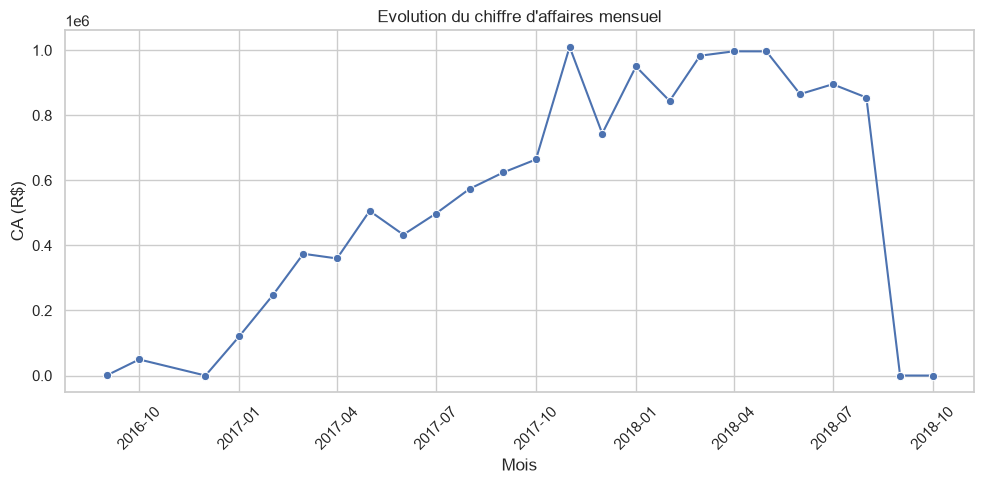

In [4]:
# KPI 1 : Evolution du CA mensuel
# ----------------------------------------------------------------------
df["mois"] = df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
ca_mensuel = df.groupby("mois")["prix_total"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=ca_mensuel, x="mois", y="prix_total", marker="o")
plt.title("Evolution du chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("CA (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("kpi1_ca_mensuel.png", dpi=150)
plt.show()

# Insight a commenter dans le notebook :
# - identifier la tendance generale (croissance / stagnation)
# - reperer d'eventuels pics saisonniers (ex: Black Friday au Bresil = novembre)

C:\Users\chokr\AppData\Local\Temp\ipykernel_1840\278598404.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, y="product_category_name_english", x="price", palette="viridis")


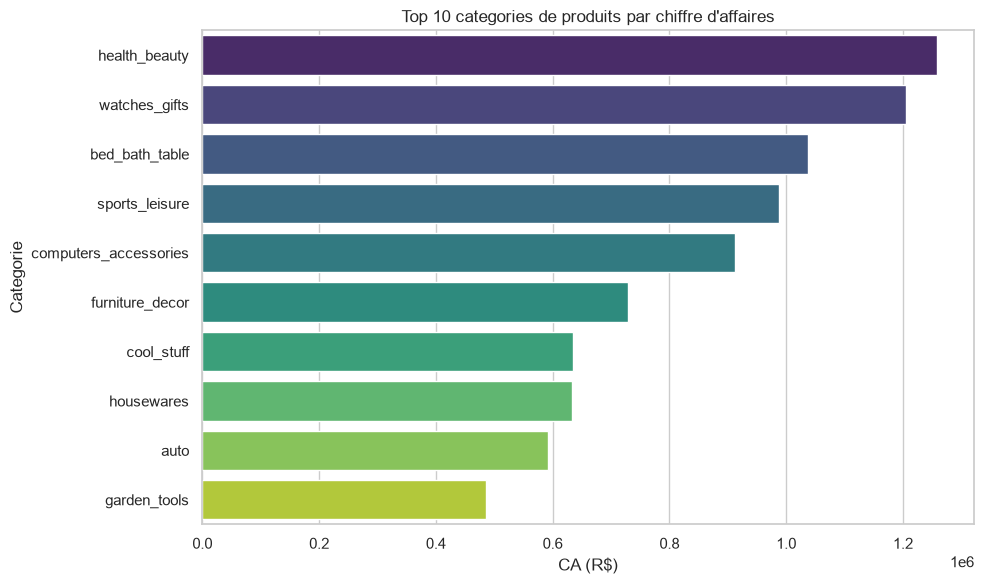

In [5]:
# KPI 2 : Top 10 categories de produits par CA
# ----------------------------------------------------------------------
# Necessite la jointure avec order_items detaille + products si pas deja fait
# (ici on suppose une colonne product_category_name_english presente apres jointure detaillee)
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

products = products.merge(category_translation, on="product_category_name", how="left")
items_cat = order_items.merge(products[["product_id", "product_category_name_english"]], on="product_id", how="left")

top_categories = (
    items_cat.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_categories, y="product_category_name_english", x="price", palette="viridis")
plt.title("Top 10 categories de produits par chiffre d'affaires")
plt.xlabel("CA (R$)")
plt.ylabel("Categorie")
plt.tight_layout()
plt.savefig("kpi2_top_categories.png", dpi=150)
plt.show()

# Insight a commenter :
# - quelles categories portent l'essentiel du revenu (effet Pareto ?)
# - coherence avec une strategie produit / marketing

C:\Users\chokr\AppData\Local\Temp\ipykernel_1840\3976394388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_note_delai, x="review_score", y="delai_livraison_jours", palette="coolwarm")


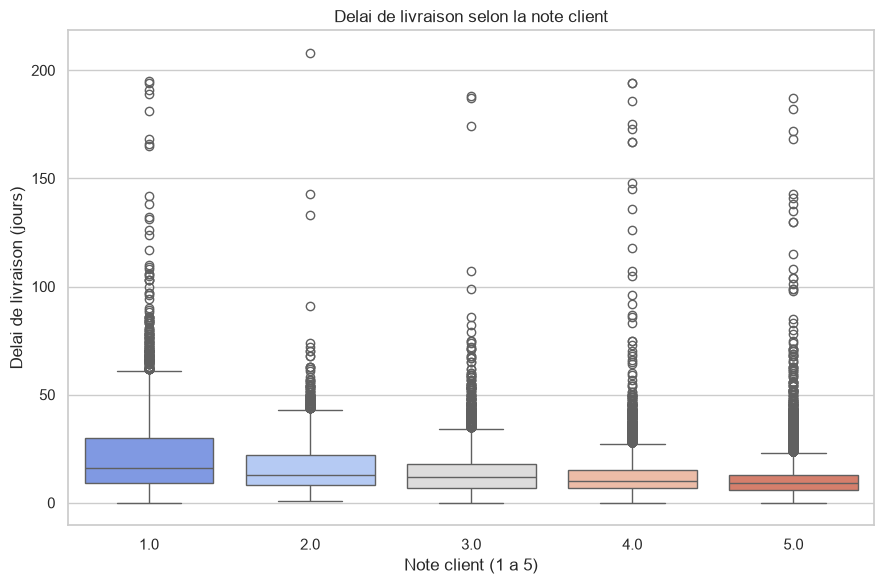

In [6]:
# KPI 3 : Delai de livraison vs note client (boxplot)
# ----------------------------------------------------------------------
df_note_delai = df_livre.dropna(subset=["review_score", "delai_livraison_jours"])

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_note_delai, x="review_score", y="delai_livraison_jours", palette="coolwarm")
plt.title("Delai de livraison selon la note client")
plt.xlabel("Note client (1 a 5)")
plt.ylabel("Delai de livraison (jours)")
plt.tight_layout()
plt.savefig("kpi3_delai_vs_note.png", dpi=150)
plt.show()

# Insight a commenter :
# - est-ce que les delais longs sont associes a de moins bonnes notes ?
# -> argument pour prioriser l'optimisation logistique

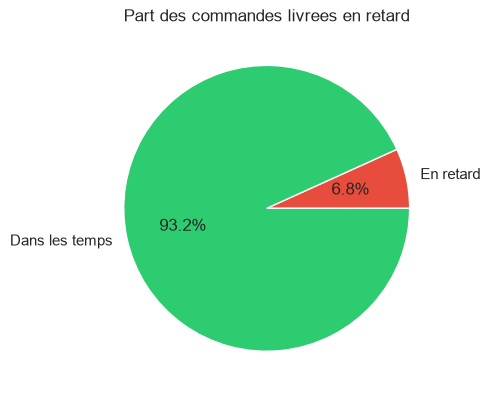

np.float64(6.77252845208234)

In [7]:
# KPI 4 : % de commandes livrees en retard
# ----------------------------------------------------------------------
df_livre["en_retard"] = df_livre["retard_estime_jours"] > 0
taux_retard = df_livre["en_retard"].mean() * 100

plt.figure(figsize=(5, 5))
plt.pie(
    [taux_retard, 100 - taux_retard],
    labels=["En retard", "Dans les temps"],
    autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"],
)
plt.title("Part des commandes livrees en retard")
plt.tight_layout()
plt.savefig("kpi4_taux_retard.png", dpi=150)
plt.show()

taux_retard  # affichage direct dans Jupyter (sortie de cellule)

# Insight a commenter :
# - ce taux est-il eleve ? a mettre en regard du KPI 3 (impact sur la note)
# -> conclusion business : recommandation d'action sur la logistique
